In [3]:
import pandas as pd
import sqlite3
from google.colab import files
uploaded = files.upload()

Saving customer_orders.csv to customer_orders.csv
Saving payments.csv to payments.csv


In [4]:
payments = pd.read_csv('payments.csv')
orders = pd.read_csv('customer_orders.csv')

In [5]:
conn = sqlite3.connect(':memory:')

In [6]:
payments.to_sql('payments', conn, index=False, if_exists='replace')
orders.to_sql('customer_orders', conn, index=False, if_exists='replace')

15000

In [19]:
allowed_types_numeric = (int, float)
print("Rows where customer_id is NOT int or float:")
print(orders[~orders['customer_id'].apply(lambda x: isinstance(x, allowed_types_numeric))])
print("-" * 50)
print("Rows where order_amount is NOT int or float:")
print(orders[~orders['order_amount'].apply(lambda x: isinstance(x, allowed_types_numeric))])
print("-" * 50)

Rows where customer_id is NOT int or float:

Empty DataFrame
Columns: [order_id, customer_id, order_date, order_amount, shipping_address, order_status, order_month]
Index: []
--------------------------------------------------
Rows where order_amount is NOT int or float:

Empty DataFrame
Columns: [order_id, customer_id, order_date, order_amount, shipping_address, order_status, order_month]
Index: []
--------------------------------------------------


In [16]:
print("Missing (NaN/null) values in 'orders' dataframe:\n")
print(orders.isnull().sum())
print("\n" + "="*50 + "\n")
print("Missing (NaN/null) values in 'payments' dataframe:\n")
print(payments.isnull().sum())


Missing (NaN/null) values in 'orders' dataframe:

order_id            0
customer_id         0
order_date          0
order_amount        0
shipping_address    0
order_status        0
order_month         0
dtype: int64


Missing (NaN/null) values in 'payments' dataframe:

payment_id        0
order_id          0
payment_date      0
payment_amount    0
payment_method    0
payment_status    0
dtype: int64


<ipython-input-13-37ce0a252f1f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retention['value'] = 1
<ipython-input-13-37ce0a252f1f>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_retention.index, y='repeat_customers', data=monthly_retention, palette='Blues_d')


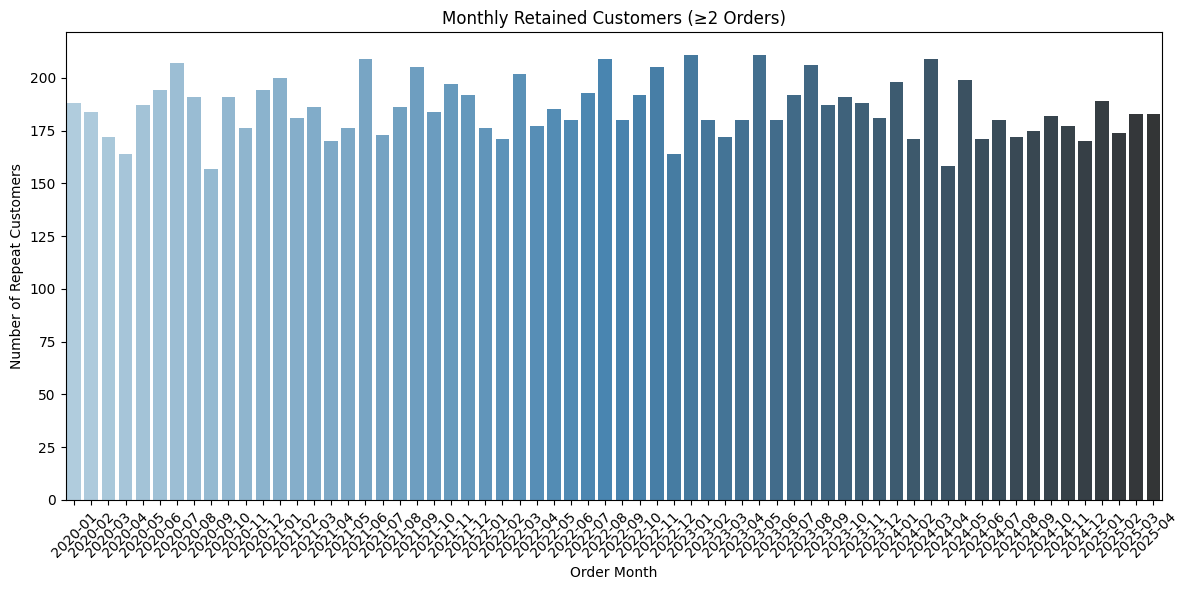

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders['order_month'] = orders['order_date'].dt.to_period('M').astype(str)
repeat_customers = orders['customer_id'].value_counts()
repeat_customers = repeat_customers[repeat_customers >= 2].index
orders = orders[orders['customer_id'].isin(repeat_customers)]
#Create a retention matrix (Customer vs Month)
retention = orders.drop_duplicates(subset=['customer_id', 'order_month'])
retention['value'] = 1
retention_matrix = retention.pivot_table(
    index='customer_id',
    columns='order_month',
    values='value',
    fill_value=0
)

#Sum how many customers returned each month (rows = cohorts, columns = months)
monthly_retention = retention_matrix.sum(axis=0).to_frame(name='repeat_customers')

#Plot retention trend over months
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_retention.index, y='repeat_customers', data=monthly_retention, palette='Blues_d')
plt.title('Monthly Retained Customers (≥2 Orders)')
plt.ylabel('Number of Repeat Customers')
plt.xlabel('Order Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
